In [32]:
# Authors:
# Antonio del Rio Chanona                     https://www.imperial.ac.uk/people/a.del-rio-chanona
# Damien van de Berg                          https://dv516.github.io/about/
# Special thanks to Edgar Ivan Sanchez Medina https://www.mpi-magdeburg.mpg.de/person/103552/1732070

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

The first part of this notebook is a recap from the course.

# **1. Optimization basics**

An optimization problem has the form

\begin{equation}
\begin{aligned}
\min_{x \in X} \quad & f(x)\\
\end{aligned}
\end{equation}

The vector $x = [x_1,..., x_n]^T$ is the optimization variable of the problem, the function $f : \mathbb{R}^n \to \mathbb{R} $ is the objective function. A vector $x^⋆$ is called optimal, if it has the smallest objective value among all vectors within the domain $X$.

**Global and local optima**

An optimal solution $x^*$ is said to be the global optimum when $f(x^*) \leq f(x),  \forall x \in X$. When this condition is met only whitin a certain neightborhood, the solution is called local optimum.




# **2. Gradient descent**

The optimization methods known as "descent methods" minimize a function by applying the following update rule at each iteration:   

\begin{equation}
x^{(k+1)} = x^{(k)} +  \alpha^{(k)} \Delta x^{(k)}
\end{equation}

in this rule, $\Delta^{(k)}$ denotes the **direction** at the iteration $k$, and $\alpha^{(k)} \geq 0$ is a scalar value called **step size** (or learning rate in machine learning). These methods are called descent methods, because at each iteration $f \left(x^{(k+1)} \right) \leq  f \left(x^{(k)} \right)$.

In the method called *Gradient Descent* the direction is chosen to be the negative of the gradient: $ \Delta x := - \nabla f(x) $. therefore, the algorithm is:

**Algorithm**

1. Given a starting point $x \in X$.
2. Repeat
3. $~~~~~~$ $ \Delta x := - \nabla f(x) $
2. $~~~~~~$ Choose $\alpha$.
3. $~~~~~~$ Update: $ x \leftarrow x +  \alpha \Delta x$
4. until stopping criterion is met.



In [33]:
############################
# --- Gradient Descent --- #
############################

def gradient_descent(f, x0, grad_f, lr, max_iter=1e5, grad_tol=1e-4, traj=False):
    '''
    Gradient Descent
    INPUTS:
        f        : Function
        x0       : Initial guess
        grad_f   : Gradient function
        lr       : Learning rate
        max_iter : Maximum number of iterations
        grad_tol : Tolerance for gradient approximation
        plot     : Boolean for plotting
    OUTPUTS:
        x        : Optimal point
        iter_i   : Number of iterations needed
    '''

    # initialize problem
    x      = np.copy(x0)
    iter_i = 0
    grad_i = grad_tol*10

    # plotting
    if traj == True:
        x_list = []
        f_list = []
        x_list.append(x.flatten().tolist())
        f_list.append(f(x))

    # optimization loop
    while np.sum(np.abs(grad_i)) > grad_tol and iter_i < max_iter:

        grad_i  =  grad_f(f,x)
        x       =  x - lr*grad_i

        iter_i += 1

        # plotting
        if traj == True:
            x_list.append(x.flatten().tolist())
            f_list.append(f(x))

    print(' Optimization using Gradient Descent \n')
    print('Iterations: ', iter_i)
    print('Optimal x : ', x)
    print('Final grad: ', grad_i)

    # trajectory
    if traj == True:
        return x, x_list, f_list,

    return x, iter_i

## Finite differences

One way to approximate the gradient of a function  is via the **finite differences method**. There exist three main types of finite difference approximations:

* Backward difference  $f'(x) \approx \frac{f(x_k) - f(x_k - \epsilon)}{\epsilon}$
* Forward difference  $f'(x) \approx \frac{f(x_k + \epsilon) + f(x_k)}{\epsilon}$
* Central difference $f'(x) \approx \frac{f(x_k + \frac{\epsilon}{2}) - f(x_k - \frac{\epsilon}{2})}{\epsilon}$

However, the central difference approximation gives the most accurate one among these three. Therefore, let's implement that one here.


In [34]:
######################################
# --- Central finite differences --- #
######################################

def central_finite_diff(f, x):
    '''
    Central finite differences approximation.
    INPUTS:
        f  : Function
        x  : Position where to approximate the gradient
    OUTPUTS:
        grad: Approximation of the gradient of f at x
    '''
    dim = x.shape[1]
    eps = np.sqrt(np.finfo(float).eps)
    grad = np.zeros((1, dim))

    for i in range(dim):
        e = np.zeros((1, dim))
        e[0, i] = eps / 2
        grad[0, i] = (f(x + e) - f(x - e)) / eps

    return grad

The next cell contains the test function that we are going to use here, but this can be replace by any function. In order to approximate the gradients we are going to use the central finite differences method with five-points.

In [36]:
def Rosenbrock_f(x):
    '''
    Rosenbrock function
    '''
    n = np.shape(x)[1]
    z = np.sum(100*(x[:,1:] - x[:,:n-1]**2)**2 + (x[:,:n-1] - 1)**2, axis=1)
    return z

###############################################
# --- Central finite differences 5 points --- #
###############################################

def central_finite_diff5(f, x):
      '''
      Five-points method for central finite differences.
      INPUTS:
          f  : Function
          x  : Position where to approximate the gradient
      OUTPUTS:
          grad: Approximation of the gradient of f at x
      '''
      dim = x.shape[1]
      # Step-size is taken as the square root of the machine precision
      eps  = np.sqrt(np.finfo(float).eps)
      grad = np.zeros((1,dim))

      for i in range(dim):
          e           = np.zeros((1,dim))
          e[0,i]      = eps
          grad_approx = (f(x - 2*e) - 8*f(x - e) + 8*f(x + e) - f(x + 2*e) )/(12*eps)
          grad[0,i]   = grad_approx

      return grad

In [37]:
# --- Gradient Descent --- #
x0 = np.array([-1.,-1.]).reshape(1,-1)

xf, x_list, f_list = gradient_descent(Rosenbrock_f, x0, central_finite_diff5, 0.001, traj=True)

<ipython-input-36-01a8d813047e>:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0,i]   = grad_approx


 Optimization using Gradient Descent 

Iterations:  20543
Optimal x :  [[0.9999167  0.99983307]]
Final grad:  [[-3.32842688e-05 -6.66961950e-05]]


## Plot function

This is the plot routine that we will be using to visualize the algorithms trajectories.

In [35]:
def plot_optimization_trajectory(x_list, f_list, func, title='Optimization Trajectory', levels=50,
                                 cmap="viridis", figsize=(8, 6)):
    """
    Plot the trajectory of an optimization algorithm on a contour plot.
    """

    x_array = np.array(x_list).reshape(-1, 2)
    f_array = np.array(f_list)

    xlim    = (min(x_array[:,0]), max(x_array[:,0]))
    ylim    = (min(x_array[:,1]), max(x_array[:,1]))

    x_vals = np.linspace(xlim[0], xlim[1], 400)
    y_vals = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = func(np.c_[X.ravel(), Y.ravel()].reshape(-1, 2)).reshape(X.shape)

    x_array = np.array(x_list).reshape(-1, 2)
    f_array = np.array(f_list)

    fig, ax = plt.subplots(figsize=figsize)
    contour = ax.contourf(X, Y, np.log(Z + 1e-8), levels=levels, cmap=cmap, alpha=0.4)
    fig.colorbar(contour, ax=ax, label='Log(Function value)')  # tighter scoping

    ax.plot(x_array[:, 0], x_array[:, 1], 'r.-', label='Optimization path')
    ax.scatter(x_array[0, 0], x_array[0, 1], color='blue', label='Start', zorder=5)
    ax.scatter(x_array[-1, 0], x_array[-1, 1], color='green', label='End', zorder=5)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

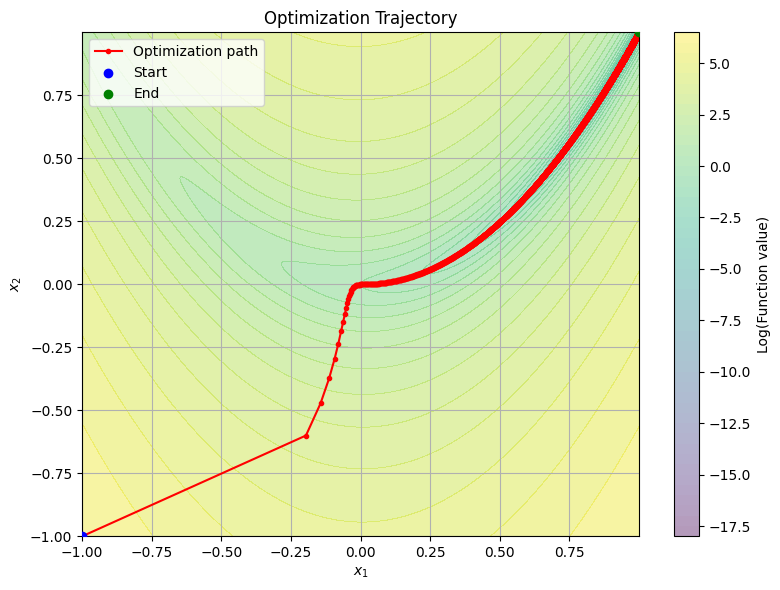

In [38]:
plot_optimization_trajectory(x_list, f_list, Rosenbrock_f)

# **3. Steepest descent**

By contrast, the steepest descent method uses the steepest descent direction (as opposed to the negative gradient in Gradient Descent) as the direction to move to at each iteration.

In order to find the steepest direction, we can approximate
the function via a first-order Taylor expansion:

\begin{equation}
f(x + \Delta x) \approx f(x) + \nabla f(x)^T \Delta x
\end{equation}

The second term of this approximation, $\nabla f(x)^T \Delta x$,  gives the approximate change in $f$ for a small step $\Delta x$. Therefore, to minimize the function $f$ we have to make this second term, $\nabla f(x)^T \Delta x$, as negative as possible. To do this, we have to choose the step $\Delta x$ such that $\Delta x = \text{argmin} \{ \nabla f(x)^T \Delta x | \| \Delta x \| =1 \}$. The constraint, $\| \Delta x \| = 1$, ensures that the solution to this problem is sensible, othewise a very large $\Delta x$ would always be chosen.

**Algorithm**

1. Given a starting point $x \in X$.
2. Repeat
3. $~~~~~~$ $ \Delta x := \|f(x)\| \ast \text{argmin} \{ \nabla f(x)^T \Delta x | \| \Delta x \| =1 \} $
2. $~~~~~~$ Choose $\alpha$.
3. $~~~~~~$ Update: $ x = x +  \alpha \Delta x$
4. until stopping criterion is met.

In general, we may consider various norms for the minimization problem. And the interpretation of steepest descent with different norms leads to different algorithms. For example, by using the $l_2$ norm:

\begin{equation}
\Delta x = \text{argmin} \{ \nabla f(x)^T \Delta x | \| \Delta x \|_2 =1 \}
\end{equation}

From the Cauchy-Schwarz inequality we know that

\begin{equation}
\nabla f(x)^T \Delta x \leq \| \nabla f(x) \| \| \Delta x \|
\end{equation}

with equality when $\Delta x = \lambda \nabla f(x)$, $\lambda \in \mathbb{R}$. Since $ \| \Delta x \| = 1$ and we want to minimize:

\begin{equation}
\Delta x^* = - \frac{\nabla f(x)}{\| \nabla f(x) \|}
\end{equation}

and the update rule becomes exactly equal to the Gradient Descent one (this is not the case if we take a different norm). For this reason we say that Gradient Descent is just a special case of Steepest Descent.

#### **Exact line search**

Ideally we would need to take the step size $\alpha$ (aka learning rate in the Machine Learning field) that minimizes the funtion at the next point. In other words we would need to solve the following in order to get the optimal step size at each iteration:

\begin{equation}
\alpha^* \in \text{argmin}_{\alpha \geq 0} ~~~ f \left( x^{(k)} - \alpha \nabla f \left(x^{(k)} \right) \right)
\end{equation}

Solving the above problem is known as *exact line search*, but this would require to solve an adittional optimization problem that can be computationaly expensive in most applications. Therefore, the learning rate $\alpha$ is most of the times chosen heuristically or using other approximations to the exact line search (e.g. backtracking).

#### **Backtracking line search**

As mentioned before, backtracking line search is one of the approximation methods for the exact line search, and it relies on two constants $A$ and $B$, such that $0 < A < 0.5$ and $0 < B < 1$. The role of the constant $A$ is to reduce the slope of the line in which the search will be performed (see following plot), and the constant $B$ weights the previous learning rate $\alpha$.

![alt text](https://drive.google.com/uc?id=1foXJkVjqcSmP4GN3nmhEdHFUBP48DYCP)


Therefore, at each iteration we would have:

* Set $\alpha = 1$
* While the following condition holds: $f \left( x - \alpha \nabla f(x) \right) > f(x) - A \alpha \nabla f(x)^T \nabla f(x)$, reduce $\alpha$ according to the following: $\alpha := B \alpha$. The inequality condition used here is known as the Armijo–Goldstein condition.

Typical values for these two constants are $A = [0.01, 0.3]$ and $B = [0.1, 0.8]$.

# **4. Gradient descent with momentum**

The idea behind this extension is to avoid most of the (unnecesary) zig-zag movements of Gradient descent by accumulating momentum along the direction towards the optimum while we iterate.

Therefore, the update rule of Gradient Descent is modified like this:

\begin{equation}
x^{(k+1)} = x^{(k)} + v^{(k)}
\end{equation}

where $v^{(k)}$ is the velocity term defined by:

\begin{equation}
v^{(k)} = \beta v^{(k-1)} - \alpha \nabla f(x^{(k)})
\end{equation}

where $\beta \in [0,1]$ is the momentum hyperparameter commonly set to 0.9 in Deep Learning problems, but to more moderate values like 0.3 in other types of problems.

In [39]:
####################
# --- Momentum --- #
####################

def momentum(grad_i, v_prev, lr, beta=0.9):
    '''
    Momentum function
    INPUTS:
        grad_i  : Gradient of function at current position
        v_prev  : velocity value at the previous position
        beta    : Momentum hyperparameter
    OUTPUTS:
        v       : Velocity term
    '''

    v = beta * v_prev - lr * grad_i

    return v

#######################
# --- Line search --- #
#######################

def ls(grad_i, x, f, lr=1e-2):
    '''
    Line search for determining learning rate

    **This is the simple version of a line-search:
    **You accept a new point as long as it is better than the current one.

    INPUTS:
        grad_i  : Gradient of function at current position
        x       : Current position
        f       : Objective function
    OUTPUTS:
        lr    : Optimal learning rate
        iter  : Number of iterations needed in line search
    '''

    iter = 0

    while f(x - lr * grad_i) > f(x):
        lr *= 0.5
        iter += 1

    return lr, iter

#######################
# --- Line search --- #
#######################

def line_search(grad_i, x, f, A=0.1, B=0.8, lr=1e-2):
    '''
    Line search for determining learning rate

    **This is the more sophisticated version of a line-search:
    **You accept a new point only if it lies between the two slopes as illustrated above.

    INPUTS:
        grad_i  : Gradient of function at current position
        x       : Current position
        f       : Objective function
    OUTPUTS:
        lr    : Optimal learning rate
        iter  : Number of iterations needed in line search
    '''

    iter = 0
    fx = f(x)

    while f(x - lr * grad_i) > fx - A * lr * np.sum(grad_i * grad_i):
        lr *= B
        iter += 1

    return lr, iter

In [40]:
##########################################################
# --- Gradient Descent with line search and momentum --- #
##########################################################

def GD_ls_momentum(f, x0, grad_f, beta=0.9, max_iter=1e5, grad_tol=1e-4, traj=False):
    '''
    Gradient Descent with line search and momentum
    INPUTS:
        f        : Function
        x0       : Initial guess
        grad_f   : Gradient function
        beta     : Parameter beta for the momentum calculation
        max_iter : Maximum number of iterations
        grad_tol : Tolerance for gradient approximation
        plot     : Boolean for plotting
    OUTPUTS:
        x        : Optimal point
        iter_i   : Number of iterations needed
    '''

    # initialize problem
    x      = np.copy(x0)
    iter_i = 0
    grad_i = grad_tol*10

    # plotting
    if traj == True:
        x_list = []
        f_list = []
        x_list.append(x.flatten().tolist())
        f_list.append(f(x))

    # optimization loop
    v_prev = 0      # initialize at zero to get normal GD at first step
    while np.sum(np.abs(grad_i)) > grad_tol and iter_i < max_iter:
        grad_i  = grad_f(f,x)                               # compute gradient
        lr      = line_search(grad_i, x, f)[0]              # compute learning rate using line search
        v       = momentum(grad_i, v_prev, lr, beta=beta)   # compute momentum
        x       = x + v                                     # compute step
        v_prev  = v                                         # update previous momentum term
        iter_i += 1

        # plotting
        if traj == True:
            x_list.append(x.flatten().tolist())
            f_list.append(f(x))

    print(' Optimization using Gradient Descent with momentum \n')
    print('Iterations: ', iter_i)
    print('Optimal x : ', x)
    print('Final grad: ', grad_i)

    # trajectory
    if traj == True:
        return x, x_list, f_list,

    return x, iter_i

In [41]:
# --- Gradient Descent with line search and momentum --- #
x0 = np.array([-1.,-1.]).reshape(1,-1)

xf, x_list, f_list = GD_ls_momentum(Rosenbrock_f, x0, central_finite_diff5, beta=0.3, traj=True)

<ipython-input-36-01a8d813047e>:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0,i]   = grad_approx


 Optimization using Gradient Descent with momentum 

Iterations:  5017
Optimal x :  [[0.99993164 0.99986325]]
Final grad:  [[ 1.42641440e-05 -7.54974321e-05]]


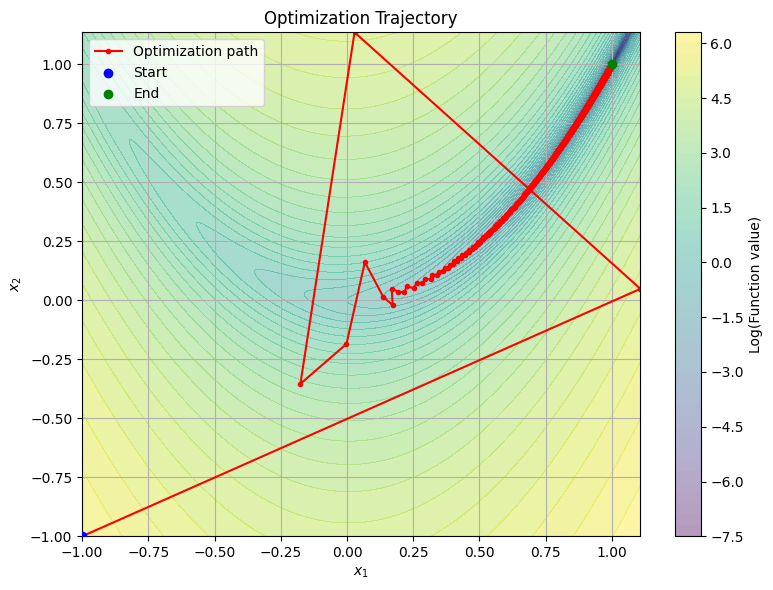

In [42]:
plot_optimization_trajectory(x_list, f_list, Rosenbrock_f)

# **5. Nesterov Accelerated Gradient Descent**

The Nesterov Accelerated Gradient Descent (NAG) is a further improvement to the Gradient Descent with momentum algorithm. The step direction in NAG is calculated based on the gradient on an approximated future position instead of the current position, in this way, more gradient information is included into the update step compared to the traditional momentum approach.

Therefore, the velocity term in NAG is determined by:

$v^{(k)} = \beta v^{(k-1)} - \alpha \nabla f(\tilde{x}^{(k)})$

where $\tilde{x}^{(k)}$ is the approximated future position calculated as:

$\tilde{x}^{(k)} = x^{(k)} + \beta v^{(k-1)}$



In [43]:
def NAG(f, x0, grad_f, beta=0.9, max_iter=1e5, grad_tol=1e-4, traj=False):
    '''
    Nesterov Accelerated Gradient Descent with line search
    '''
    x = np.copy(x0)
    iter_i = 0
    v_prev = 0
    grad_i = grad_tol * 10

    if traj:
        x_list = [x.flatten().tolist()]
        f_list = [f(x)]

    while np.sum(np.abs(grad_i)) > grad_tol and iter_i < max_iter:

        x_tilde = x + beta * v_prev               # lookahead
        g_tilde = grad_f(f, x_tilde)              # gradient at lookahead
        grad_i  = g_tilde                         # for stopping criterion
        lr, _   = line_search(g_tilde, x_tilde, f)
        v       = beta * v_prev - lr * g_tilde
        x       = x + v
        v_prev  = v
        iter_i += 1

        if traj:
            x_list.append(x.flatten().tolist())
            f_list.append(f(x))

    print(' Optimization using NAG \n')
    print('Iterations: ', iter_i)
    print('Optimal x : ', x)
    print('Final grad: ', grad_i)

    if traj:
        return x, x_list, f_list
    return x, iter_i

In [44]:
# --- NAG --- #
x0 = np.array([-1.,-1.]).reshape(1,-1)

xf, x_list, f_list = NAG(Rosenbrock_f, x0, central_finite_diff5, beta=0.3, traj=True)

<ipython-input-36-01a8d813047e>:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0,i]   = grad_approx


 Optimization using NAG 

Iterations:  100000
Optimal x :  [[0.97508833 0.96084782]]
Final grad:  [[ 6.29511738 -3.20794357]]


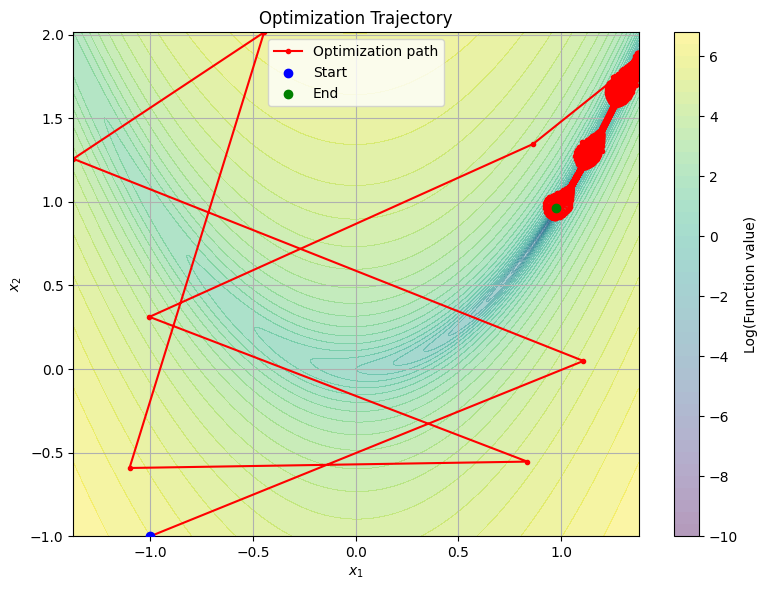

In [45]:
plot_optimization_trajectory(x_list, f_list, Rosenbrock_f)

# **6. AdaGrad**

We have been using line search as a way to determine a reasonable value for the learning rate. However, in such approach, the learning rate $\alpha$ is a unique value that is applied in all dimensions of the gradient. Can you see the problem of this? Imagine you have different ranges on each dimension of the gradient, then the learning rate will favour each dimension differently. One straightforward approach would be to have a learning rate for each dimension, i.e. the $\alpha$ would be a vector instead of a scalar. The problem with this is that in many applications you can easily end-up with thousand or millions of dimensions (think about a Deep Neural Network). Therefore, one of the first approaches to this problem was AdaGrad, which adaptively scale the learning rate for each dimension. Another advantage is that we do not have to adjust the learning rate manually, as this is adaptively adjusted.

The way in which AdaGrad does what we explained above is to update the position according to:

$x^{(k)} = x^{(k)} - \alpha \frac{\nabla f(x^{(k)})}{V^{(k)}}$

where $V^{(k)}$ is the accumulate historical gradient that is calculated as:

$V^{(k)} = \sqrt{\sum_{i=1}^{k} \left(\nabla f(x^{(k)})\right)^2 + \epsilon}$

where $\epsilon$ is just a small number that prevents the division by zero.


In [63]:
############################################
# --- Gradient historical accumulation --- #
############################################

def grad_accumulation(g_traj, eps=1e-8):
    '''
    Gradient historical accumulation
    Note: A vectorized form might be more efficient, but we will keep it like
          this, for educational purposes.
    INPUTS:
        g_traj  : List of historical gradients
        eps     : small number to prevent division by zero
    OUTPUTS:
        V       : Gradient accumulation
    '''

    dim    = g_traj[0].shape[1]
    g_traj = np.array(g_traj).reshape(-1, dim)
    V      = np.sum(g_traj ** 2, axis=0, keepdims=True)

    return V

In [68]:
###################
# --- AdaGrad --- #
###################

def adagrad(f, x0, grad_f, max_iter=1e4, grad_tol=1e-4, traj=False):
    '''
    AdaGrad optimization algorithm
    INPUTS:
        f        : Function
        x0       : Initial guess
        grad_f   : Gradient function
        max_iter : Maximum number of iterations
        grad_tol : Tolerance for gradient approximation
        plot     : Boolean for plotting
    OUTPUTS:
        x        : Optimal point
        iter_i   : Number of iterations needed
    '''

    x = np.copy(x0)
    iter_i = 0
    grad_i = grad_tol * 10
    g_traj = []

    if traj:
        x_list = [x.flatten().tolist()]
        f_list = [f(x)]

    while np.sum(np.abs(grad_i)) > grad_tol and iter_i < max_iter:

        grad_i = grad_f(f, x)
        g_traj.append(grad_i)

        lr = 1e-3
        if iter_i == 0:
            x = x - lr * grad_i
        else:
            V = grad_accumulation(g_traj)
            x = x - (lr / (np.sqrt(V) + 1e-8)) * grad_i

        iter_i += 1

        if traj:
            x_list.append(x.flatten().tolist())
            f_list.append(f(x))

        if iter_i % 2000 == 0:
            print('Current iteration:', iter_i, '| f(x):', f(x))

    print('\nOptimization using AdaGrad')
    print('Iterations:', iter_i)
    print('Optimal x:', x)
    print('Final grad norm:', np.linalg.norm(grad_i))

    if traj:
        return x, x_list, f_list
    return x, iter_i

In [69]:
# --- AdaGrad --- #
x0 = np.array([-1.,-1.]).reshape(1,-1)

xf, x_list, f_list = adagrad(Rosenbrock_f, x0, central_finite_diff5, traj=True)

<ipython-input-36-01a8d813047e>:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0,i]   = grad_approx


Current iteration: 2000 | f(x): [30.37024172]
Current iteration: 4000 | f(x): [26.07134821]
Current iteration: 6000 | f(x): [23.18576883]
Current iteration: 8000 | f(x): [20.99716522]
Current iteration: 10000 | f(x): [19.23368973]

Optimization using AdaGrad
Iterations: 10000
Optimal x: [[-0.0704945  -0.42032726]]
Final grad norm: 86.2275736617009


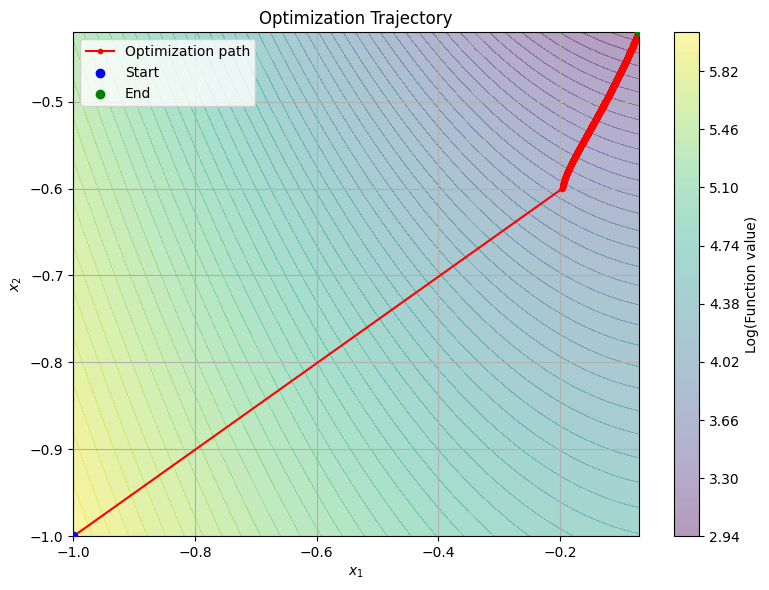

In [70]:
plot_optimization_trajectory(x_list, f_list, Rosenbrock_f)

As you can see, the problem becomes evident: **for this problem AdaGrad is super slow!**
This is because, of course, by reducing the gradient at each iteration the steps that we take are very small. And, since we are accumulating the gradients, we are reducing the gradient by a larger amount at each iteration. Therefore, the nice feature of AdaGrad of taking care of the different ranges in the dimensions of the gradient comes at the expense of very slow convergence.

This takes us to an important point in optimization: **Always scale your features!**

You can use [standarization or min-max sclaing](https://en.wikipedia.org/wiki/Feature_scaling) for example, but the idea of scaling your features is that you overcome this difficulty of having enormous differences in the ranges in your gradient.

# **7. AdaDelta**

AdaDelta is an extension of AdaGrad that tries to overcome the slow convergence by not considering all the accumulated historical gradients, but only the gradients in a certain window over a given period. This is accomplished by calculating $V^{(k)}$ as follows:

$V^{(k)} = \sqrt{\rho V^{(k-1)} + (1-\rho) \left(\nabla f(x^{(k)})\right)^2 + \epsilon}$

where $\rho$ is a exponential decay parameter, usually set to 0.95. The reason for this specific form is that, instead of inneficiently store $w$ number of gradients, the same calculation can be obtained as the exponentially decaying average of the squared gradients that we see in the above expression.

In the [original paper](https://arxiv.org/pdf/1212.5701.pdf), the authors noted that the hypothetical units in the update are not consistent. Hence, they defined an accumulation term also for the parameters updates. For this reason, they also definied the accumulation of the parameter updates as follows:

$E^{(k)} = \sqrt{\rho E^{(k-1)} + (1-\rho) \Delta {x^{(k)}}^2 + \epsilon}$

and since  $\Delta x^{(k)}$ is unknown at the current iteration, it is approximated using the previous position as:

$ \Delta x^{(k)} = - \frac{E^{(k-1)}}{V^{(k)}} \nabla f(x^{(k)}) $

In [50]:
####################
# --- AdaDelta --- #
####################

def adadelta(f, x0, grad_f, rho=0.95, eps=1e-8, max_iter=1e4, grad_tol=1e-4, traj=False):
    '''
    AdaDelta optimization algorithm
    INPUTS:
        f        : Function
        x0       : Initial guess
        grad_f   : Gradient function
        rho      : Exponential decay parameter
        eps      : Small constant to avoid division over zero
        max_iter : Maximum number of iterations
        grad_tol : Tolerance for gradient approximation
        plot     : Boolean for plotting
    OUTPUTS:
        x        : Optimal point
        iter_i   : Number of iterations needed
    '''

    # initialize problem
    x      = np.copy(x0)
    iter_i = 0
    grad_i = grad_tol*10

    # plotting
    if traj == True:
        x_list = []
        f_list = []
        x_list.append(x.flatten().tolist())
        f_list.append(f(x))

    # optimization loop
    E_g = 0; E_x = 0
    while np.sum(np.abs(grad_i)) > grad_tol and iter_i < max_iter:
        grad_i  = grad_f(f,x)                                           # compute gradient
        E_g     = rho*E_g + (1-rho)*grad_i*grad_i                       # exponential decay average on gradients
        x_delta = - np.sqrt(E_x + eps)*grad_i/np.sqrt(E_g + eps)        # compute x_delta
        E_x     = rho*E_x + (1-rho)*x_delta*x_delta                     # exponential decay average on parameters
        x       = x + x_delta                                           # compute step
        iter_i += 1

        # plotting
        if traj == True:
            x_list.append(x.flatten().tolist())
            f_list.append(f(x))

    print(' Optimization using AdaDelta \n')
    print('Iterations: ', iter_i)
    print('Optimal x : ', x)
    print('Final grad: ', grad_i)

    # trajectory
    if traj == True:
        return x, x_list, f_list,

    return x, iter_i

In [51]:
# --- AdaDelta --- #
x0 = np.array([-1.,-1.]).reshape(1,-1)

xf, x_list, f_list = adadelta(Rosenbrock_f, x0, central_finite_diff5, rho=0.9, eps=1e-8, max_iter=3000, traj=True)

<ipython-input-36-01a8d813047e>:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0,i]   = grad_approx


 Optimization using AdaDelta 

Iterations:  3000
Optimal x :  [[0.50549919 0.25510958]]
Final grad:  [[-0.94241331 -0.04747532]]


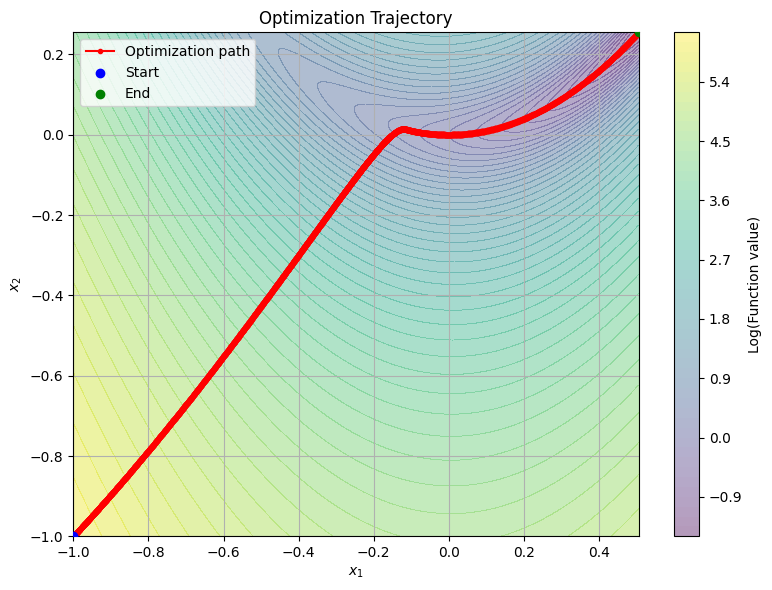

In [52]:
plot_optimization_trajectory(x_list, f_list, Rosenbrock_f)

As you can see, for this specific problem, AdaDelta does not do a good job. However, if you set the maximum number of iterations to some number, e.g. 5000, for both AdaGrad and AdaDelta and compare the results, you will see that AdaDelta jumps faster into a zone close to the optimum.

The problems on the convergence in AdaDelta has been reported in the literature (e.g. Section 4.4 of this [book](https://books.google.de/books?id=IbnEDwAAQBAJ&pg=PA189&lpg=PA189&dq=adadelta+not+converging&source=bl&ots=f2i8liEovl&sig=ACfU3U2nzVAPCLLtC3Os_cxmHmh7acOBww&hl=en&sa=X&ved=2ahUKEwjl4YLJ7MTqAhWNs4sKHQUfCrQQ6AEwA3oECAgQAQ#v=onepage&q=adadelta%20not%20converging&f=false) and [this paper](https://openreview.net/pdf?id=ryQu7f-RZ)). And even the original paper make the comparison of AdaDelta saying:

* *Setting the hyperparameters to $\epsilon=1^{-6}$ and $\rho=0.95$ we
achieve 2.00% test set error compared to the 2.10% of Schaul
et al. While this is nowhere near convergence it gives a sense
of how quickly the algorithms can optimize the classification
objective.*

You might be asking why then AdaDelta is used, even if it fails to optimize our (relatively simple) Rosenbrock function. A posible answer is: in many machine learning applications, specially in Deep learning, being close to the optimum is enough for the task we want to accomplish. And if AdaDelta takes us relatively fast to this zone, then maybe is worth considering.

Another interesting thing to note here is that even though you do not have a learning rate that has to be tunned, the hyperparameter $\epsilon$ influences the behaviour of AdaDelta quite significantly for certain problems (e.g. ours here).

<font color='blue'>Try different **combinations of the hyperparameters** $\epsilon$ and $\rho$ and see their influence in convergence. Also, **compare AdaGrad and AdaDelta** in terms of how far one goes towards the optimum in a fixed number of iterations. </font>

# **8. RMSProp**

RMSProp was proposed by Geoffrey Hinton in his [Coursera lecture](http://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf) and it is pretty much the same as the idea 1 presented at the [AdaDelta paper](https://arxiv.org/pdf/1212.5701.pdf). This idea is: adapt the learning rate using the gradiet information of the previous $w$ steps by computing the average exponential decay. Hence, RMSprop update rule is:

$x^{(k)} = x^{(k)} - \alpha \frac{\nabla f(x^{(k)})}{V^{(k)}}$

where

$V^{(k)} = \sqrt{\rho V^{(k-1)} + (1-\rho) \left(\nabla f(x^{(k)})\right)^2 + \epsilon}$

For the sake of completeness let's also implement it in such form.


In [53]:
####################
# --- RMSProp --- #
####################

def rmsprop(f, x0, grad_f, lr=0.001, rho=0.95, eps=1e-8, max_iter=1e4, grad_tol=1e-4, traj=False):
    '''
    RMSProp optimization algorithm
    INPUTS:
        f        : Function
        x0       : Initial guess
        grad_f   : Gradient function
        rho      : Exponential decay parameter
        eps      : Small constant to avoid division over zero
        max_iter : Maximum number of iterations
        grad_tol : Tolerance for gradient approximation
        plot     : Boolean for plotting
    OUTPUTS:
        x        : Optimal point
        iter_i   : Number of iterations needed
    '''

    # initialize problem
    x      = np.copy(x0)
    iter_i = 0
    grad_i = grad_tol*10

    # plotting
    if traj == True:
        x_list = []
        f_list = []
        x_list.append(x.flatten().tolist())
        f_list.append(f(x))

    # optimization loop
    V = np.zeros_like(x)
    while np.sum(np.abs(grad_i)) > grad_tol and iter_i < max_iter:

        grad_i = grad_f(f,x)                      # compute gradient
        V      = rho * V + (1 - rho) * grad_i**2  # accumulate squared gradients
        x = x - lr * grad_i / (np.sqrt(V) + eps)  # update rule

        iter_i += 1

        # plotting
        if traj == True:
            x_list.append(x.flatten().tolist())
            f_list.append(f(x))

    print(' Optimization using RMSProp \n')
    print('Iterations: ', iter_i)
    print('Optimal x : ', x)
    print('Final grad: ', grad_i)

    # trajectory
    if traj == True:
        return x, x_list, f_list,

    return x, iter_i

In [54]:
# --- RMSProp --- #
x0 = np.array([-1.,-1.]).reshape(1,-1)

xf, x_list, f_list = rmsprop(Rosenbrock_f, x0, central_finite_diff5, rho=0.9, eps=1e-8, traj=True)

<ipython-input-36-01a8d813047e>:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0,i]   = grad_approx


 Optimization using RMSProp 

Iterations:  10000
Optimal x :  [[1.00032117 0.99914252]]
Final grad:  [[-0.60084063  0.29994507]]


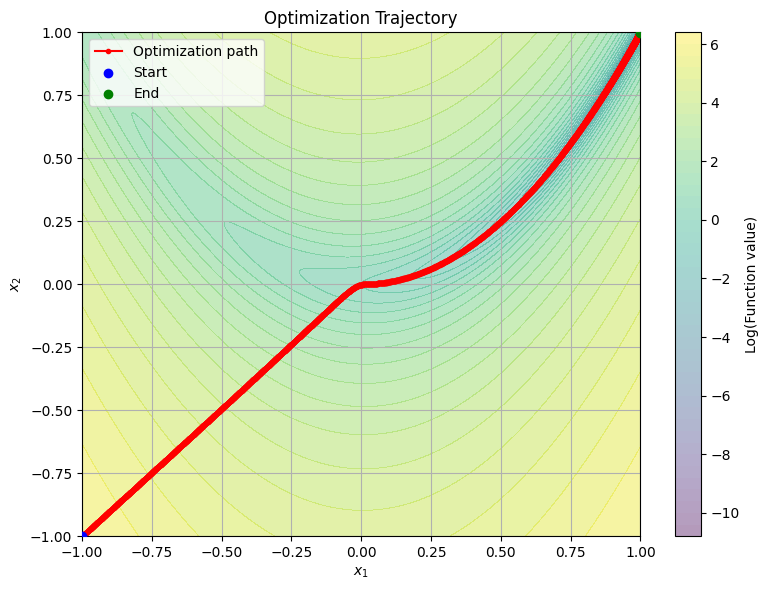

In [55]:
plot_optimization_trajectory(x_list, f_list, Rosenbrock_f)

Well, this is a surprise, the algorithm converged to the optimum if we use the RMSProp form!

Similar result was encounter in the [book](https://books.google.de/books?id=IbnEDwAAQBAJ&pg=PA189&lpg=PA189&dq=adadelta+not+converging&source=bl&ots=f2i8liEovl&sig=ACfU3U2nzVAPCLLtC3Os_cxmHmh7acOBww&hl=en&sa=X&ved=2ahUKEwjl4YLJ7MTqAhWNs4sKHQUfCrQQ6AEwA3oECAgQAQ#v=onepage&q=rmsprop&f=false) we mentioned aboved. The reason is that the accumulation of the parameters update ($E^{(k-1)}$ in AdaDelta) can act as an accelerator term at the fist iterations. However, when approximating the optimum, this same "kind of momentum" prevents the algorithm from convergence.

# **9. Adam**

Adam combines the nice key property of the momentum methods with the adaptive learning rate methods. In addition to keep the accumulation term of the squared gradients $V^{(k)}$, Adam also has an accumulation term for past gradients (like the momentum methods).

The strategy of Adam is to calculate two moments for the gradients:

*   First moment (mean):

$~~~~~~~~~~~~~~~~~ m^{(k)}=\beta_1 m^{(k-1)} + (1-\beta_1) \nabla f(x^{(k)})$

*   Second moment (uncentered variance):

$~~~~~~~~~~~~~~~~~ V^{(k)}= \beta_2 V^{(k-1)} + (1-\beta_2) \left( \nabla f(x^{(k)}) \right)^2$

where $\beta_1$ and $\beta_2$ are exponential decay rates. Recommended values for $\beta_1$, $\beta_2$ and $\epsilon$ are 0.9, 0.999 and $10^{-8}$ respectively.

However, the [authors noted](https://arxiv.org/pdf/1412.6980.pdf) that during the first iterations the method is biased towards zero. Terefore, they used bias-corrected moments defined as:

*   First bias-corrected moment (mean):

$~~~~~~~~~~~~~~~~~ \hat{m}^{(k)}=\frac{m^{(k)}}{1- \beta_1^{k}}$

*   Second moment (uncentered variance):

$~~~~~~~~~~~~~~~~~ \hat{V}^{(k)}= \frac{V^{(k)}}{1- \beta_2^{k}}$

Note the terms $\beta_1^{k}$ and $\beta_2^{k}$ are the beta values to the power of the iteration number. Therefore, the update rule for Adam is:

$x^{(k+1)} = x^{(k)} - \alpha \frac{\hat{m}^{(k)}}{\sqrt{\hat{V}^{(k)}} + \epsilon}$

<font color='blue'>Implement the **moments equations** and the **update rule** of Adam.</font>


In [56]:
################
# --- Adam --- #
################

def adam(f, x0, grad_f, lr=0.1, beta_1=0.9, beta_2=0.999, eps=1e-8, max_iter=1e4, grad_tol=1e-4, traj=False):
    '''
    Adam optimization algorithm
    INPUTS:
        f        : Function
        x0       : Initial guess
        grad_f   : Gradient function
        beta_1   : Exponential decay parameter 1
        beta_2   : Exponential decay parameter 2
        eps      : Small constant to avoid division over zero
        max_iter : Maximum number of iterations
        grad_tol : Tolerance for gradient approximation
        plot     : Boolean for plotting
    OUTPUTS:
        x        : Optimal point
        iter_i   : Number of iterations needed
    '''

    # initialize problem
    x      = np.copy(x0)
    iter_i = 0
    grad_i = grad_tol*10

    # plotting
    if traj == True:
        x_list = []
        f_list = []
        x_list.append(x.flatten().tolist())
        f_list.append(f(x))

    # optimization loop
    m = 0;  V = 0
    while np.sum(np.abs(grad_i)) > grad_tol and iter_i < max_iter:
        grad_i  = grad_f(f,x)                                           # compute gradient

        m      = beta_1 * m + (1 - beta_1) * grad_i
        V      = beta_2 * V + (1 - beta_2) * grad_i ** 2
        m_hat  = m / (1 - beta_1)
        V_hat  = V / (1 - beta_2)
        x      = x - lr * m_hat / (np.sqrt(V_hat) + eps)

        iter_i += 1

        # plotting
        if traj == True:
            x_list.append(x.flatten().tolist())
            f_list.append(f(x))

    print(' Optimization using Adam \n')
    print('Iterations: ', iter_i)
    print('Optimal x : ', x)
    print('Final grad: ', grad_i)

    # trajectory
    if traj == True:
        return x, x_list, f_list,

    return x, iter_i

In [57]:
# --- Adam --- #
x0 = np.array([-1.,-1.]).reshape(1,-1)

xf, x_list, f_list = adam(Rosenbrock_f, x0, central_finite_diff5, lr=0.05, traj=True)

<ipython-input-36-01a8d813047e>:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0,i]   = grad_approx


 Optimization using Adam 

Iterations:  6008
Optimal x :  [[0.99992339 0.99984652]]
Final grad:  [[-4.56058697e-05 -5.41459687e-05]]


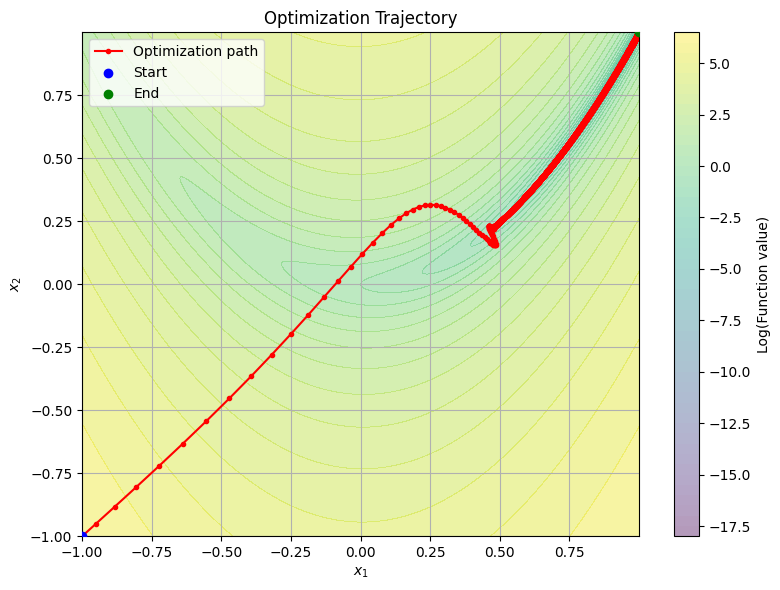

In [58]:
plot_optimization_trajectory(x_list, f_list, Rosenbrock_f)

# **10. Newton's method**

This optimization method calculates the inverse of the Hessian matrix to obtain faster convergence than the first-order gradient descent methods.

The update rule of the Newton's method is:

$ x^{(k+1)} = x^{(k)} - \left(\nabla^2 f(x^{(k)}) \right)^{-1}\nabla f(x^{(k)}) $

The second term from the right hand side of the above equation is then the Newton step, and it requires, from the inverse of the Hessian, for the Hessian matrix to be positive definite. However, for some non-convex problems the Hessian might not be invertible.

Similarly as what we did for approximating the gradient using central finite differences, we can approximate the Hessian. For the details and formulas of the Hessian approximation look [here](https://en.wikipedia.org/wiki/Finite_difference).

In [59]:
###################################################
# --- Central second order finite differences --- #
###################################################

def Second_diff_fxx(f, x):
    '''
      Central finite differences approximation of Hessian
      INPUTS:
          f  : Function
          x  : Position where to approximate the Hessian
      OUTPUTS:
          Hxx: Approximation of the Hessian of f at x
      '''

    dim   = np.shape(x)[1]
    # Step-size is taken as the square root of the machine precision
    eps  = np.sqrt(np.finfo(float).eps)
    Hxx   = np.zeros((dim,dim))

    for j in range(dim):
        # compute Fxx (diagonal elements)
        x_d_f       = np.copy(x)             # forward step
        x_d_b       = np.copy(x)             # backward step
        x_d_f[0,j]  = x_d_f[0,j] + eps
        x_d_b[0,j]  = x_d_b[0,j] - eps
        Hxx[j,j]    = (f(x_d_f) -2*f(x) + f(x_d_b))/eps**2

        for i in range(j+1,dim):
            # compute Fxy (off-diagonal elements)
            # Fxy
            x_d_fxfy    = np.copy(x_d_f)
            x_d_fxfy[0,i] = x_d_fxfy[0,i] + eps
            x_d_fxby    = np.copy(x_d_f)
            x_d_fxby[0,i] = x_d_fxby[0,i] - eps
            x_d_bxfy    = np.copy(x_d_b)
            x_d_bxfy[0,i] = x_d_bxfy[0,i] + eps
            x_d_bxby    = np.copy(x_d_b)
            x_d_bxby[0,i] = x_d_bxby[0,i] - eps
            Hxx[j,i]    = (f(x_d_fxfy) - f(x_d_fxby) - f(x_d_bxfy) + f(x_d_bxby))/(4*eps**2)
            Hxx[i,j]    = Hxx[j,i]

    return Hxx


x1       = np.array([2.,2.]).reshape(1,-1)
Hxx = Second_diff_fxx(Rosenbrock_f, x1)
print('Hxx = ',Hxx)

Hxx =  [[3072. -768.]
 [-768.    0.]]


<ipython-input-59-cae46b445aa5>:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Hxx[j,j]    = (f(x_d_f) -2*f(x) + f(x_d_b))/eps**2
<ipython-input-59-cae46b445aa5>:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Hxx[j,i]    = (f(x_d_fxfy) - f(x_d_fxby) - f(x_d_bxfy) + f(x_d_bxby))/(4*eps**2)


In [60]:
###########################
# --- Newton's Method --- #
###########################

def newton(f, x0, grad_f, H_f, max_iter=1e3, grad_tol=1e-4, traj=False):
    '''
    Newton's method

    Note: the Hessian can become ill-conditioned
    INPUTS:
        f        : Function
        x0       : Initial guess
        grad_f   : Gradient function
        H_f      : Hessian function
        max_iter : Maximum number of iterations
        grad_tol : Tolerance for gradient approximation
        traj     : Boolean for plotting
    OUTPUTS:
        x        : Optimal point
        iter_i   : Number of iterations needed
    '''

    # initialize problem
    n      = np.shape(x0)[0]
    x      = np.copy(x0)
    iter_i = 0
    grad_i = grad_tol*10

    # trajectory
    if traj == True:
            x_list = []
            f_list = []
            x_list.append(x.flatten().tolist())
            f_list.append(f(x))

    # optimization loop
    while np.sum(np.abs(grad_i)) > grad_tol and iter_i < max_iter:
        grad_i  = grad_f(f,x)                         # compute gradient
        Hxx     = H_f(f,x)                            # compute Hessian
        x       = x - (np.linalg.inv(Hxx)@grad_i.T).T # update
        iter_i += 1

        # trajectory
        if traj == True:
            x_list.append(x.flatten().tolist())
            f_list.append(f(x))

    print(" Optimization using Newton's method \n")
    print('Iterations: ', iter_i)
    print('Optimal x : ', x)
    print('Final grad: ', grad_i)

    # trajectory
    if traj == True:
        return x, x_list, f_list

    return x, iter_i

In [61]:
# --- Newton's method --- #
x0 = np.array([-1.,-1.]).reshape(1,-1)

xf, x_list, f_list = newton(Rosenbrock_f, x0, central_finite_diff5, Second_diff_fxx, traj=True)

 Optimization using Newton's method 

Iterations:  13
Optimal x :  [[1. 1.]]
Final grad:  [[-6.13768435e-06 -1.85522309e-07]]


<ipython-input-36-01a8d813047e>:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad[0,i]   = grad_approx
<ipython-input-59-cae46b445aa5>:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Hxx[j,j]    = (f(x_d_f) -2*f(x) + f(x_d_b))/eps**2
<ipython-input-59-cae46b445aa5>:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Hxx[j,i]    = (f(x_d_fxfy) - f(x_d_fxby) - f(x_d_bxfy) + f(x_d_bxby))/(4*eps**2)


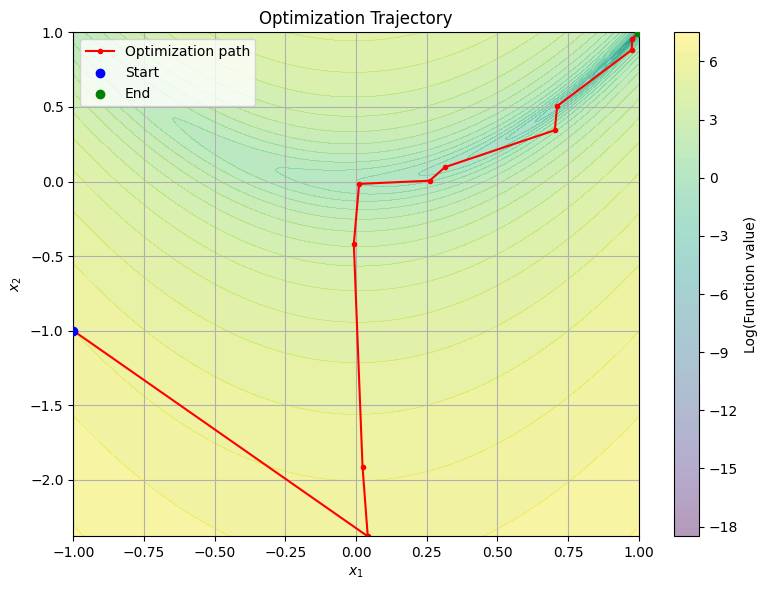

In [62]:
plot_optimization_trajectory(x_list, f_list, Rosenbrock_f)

Of course, using the Hessian information accelerates the optimization significantly! But, this comes at the expense of obtaining the Hessian and vector-matrix multiplication which is expensive in very high dimensions.